In [28]:
import sys
sys.path.append('..')

In [29]:
from data_preparation import DataPreparation
from loader.dataset_factory import DatasetFactory
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from sklearn.metrics import f1_score
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from utils import Evaluator
import itertools
import json
import numpy as np
import os
import pandas as pd
import torch

In [30]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
set_seed(42)
torch.set_float32_matmul_precision('medium')


In [31]:
# =============================================================================
# GNN Configuration
# =============================================================================
gnn_type = 'gin'
save_to_folder = 'saved_models_GIN'

# =============================================================================
# Model Architecture — Grid Search Lists
# =============================================================================
hidden_dims = [128]
out_dims = [128]
num_layers_list = [2, 3]
betas = [0.44]
mlp_hidden_dims = [128, 256]
nn_t_hidden_dims = [128, 256]

heads_list = [1]
gin_mlp_hidden_dims = [128, 256]

# =============================================================================
# Loss Weights
# =============================================================================
c1_list = [0.75]
c2_list = [0.75]
c3_list = [0.9]
laundry_weights = [2.0]

# =============================================================================
# Training & Cross-Validation
# =============================================================================
learning_rates = [0.0005]
max_norm_clipping = [5.0]

epochs_model_selection = 3000
epochs_train = 6000

minibatches = True
batch_size = 512
num_neighbors = [10, 10]

patience_selection = 100
moving_average_epochs = 5
patience_training = 200

print_every = 20
save_every = 100

# =============================================================================
# Class Imbalance
# =============================================================================
downsample = True

# =============================================================================
# Temporal Train / Validation / Test Split
# =============================================================================
date_time_1 = '2022-09-07 14:55:00'
date_time_2 = '2022-09-08 16:12:00'


import IBM AMLSim

In [32]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader(
    "ibm_amlsim", 
    engine="pyarrow", 
    dtype_backend="pyarrow", 
    nrows=None
)
# pyarrow is faster and uses less memory, it takes NumPy place

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()

Loading IBM AMLSim transactions from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Binary\..\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Binary\..\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [33]:
loader.print_features()


Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            string[pyarrow] Date and time of the transaction
From Bank            int64[pyarrow] Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              string[pyarrow] Hexadecimal ID of the sender account (node)
To Bank              int64[pyarrow] Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            string[pyarrow] Hexadecimal ID of the receiver account (node)
Amount Received      double[pyarrow] Transaction amount in the receiving currency
Receiving Currency   string[pyarrow] Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          double[pyarrow] Transaction amount in the paying currency
Payment Currency     string[pyarrow] Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin',

Data preparation

In [34]:
from data_preparation import DataPreparation
import pandas as pd

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Calcoliamo la maschera di training per evitare data leakage nello scaler
ts_raw = pd.to_datetime(transactions_df['Timestamp'])
thresh_val = pd.to_datetime(date_time_1)
train_mask_raw = ts_raw < thresh_val

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df, train_mask=train_mask_raw)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df, train_mask=train_mask_raw)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")

# Stampa bilanciamento classi (Nodi e Archi)
print("\n--- Bilanciamento Dataset ---")
num_fraud_nodes = (nodes_features_df["Is Laundering"] > 0).sum()
num_legit_nodes = len(nodes_features_df) - num_fraud_nodes
print(f"Nodi fraudolenti: {num_fraud_nodes} ({num_fraud_nodes/len(nodes_features_df)*100:.2f}%)")
print(f"Nodi leciti:      {num_legit_nodes} ({num_legit_nodes/len(nodes_features_df)*100:.2f}%)")

num_fraud_edges = (edges_features_df["Is Laundering"] > 0).sum()
num_legit_edges = len(edges_features_df) - num_fraud_edges
print(f"Archi fraudolenti: {num_fraud_edges} ({num_fraud_edges/len(edges_features_df)*100:.2f}%)")
print(f"Archi leciti:      {num_legit_edges} ({num_legit_edges/len(edges_features_df)*100:.2f}%)")

print("\n--- Features degli archi ---")
print(list(edges_features_df.columns))

print("\n--- Features dei nodi ---")
print(list(nodes_features_df.columns))


Extracting time features (Unix time, Cyclic Hour, Day of Week, Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5078345, 53)
Dimensione feature nodi: (515080, 50)

--- Bilanciamento Dataset ---
Nodi fraudolenti: 6357 (1.23%)
Nodi leciti:      508723 (98.77%)
Archi fraudolenti: 5177 (0.10%)
Archi leciti:      5073168 (99.90%)

--- Features degli archi ---
['Amount Received', 'Amount Paid', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel', 'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound', 'Receiving Currency_US Dollar', 'Receiving Currency_Yen', 'Receiving Currency_Yuan', 'Payment Currency_

In [35]:
import torch
import numpy as np
import pandas as pd

print("--- Downsampling Strategy (1:1 Ratio) ---")
# 1. Identify Fraudulent and Legitimate Nodes
# A node is fraudulent if it was involved in at least one ML transaction
fraud_nodes = nodes_features_df[nodes_features_df["Is Laundering"] > 0].index
legit_nodes = nodes_features_df[nodes_features_df["Is Laundering"] == 0].index

print(f"Total Fraudulent Nodes: {len(fraud_nodes)}")
print(f"Total Legitimate Nodes (before sampling): {len(legit_nodes)}")

# 2. Sample Legitimate Nodes (1:1 ratio)
sampled_legit_nodes = pd.Series(legit_nodes).sample(n=len(fraud_nodes), random_state=42).values

# 3. Combine to form the final set of sampled users
sampled_users = set(fraud_nodes).union(set(sampled_legit_nodes))
print(f"Total Nodes after downsampling: {len(sampled_users)}")

# 4. Filter nodes_features_df and edges_features_df efficiently
nodes_features_df = nodes_features_df.loc[list(sampled_users)]

# Filter transactions: keep only those where BOTH sender and receiver are in sampled_users
edges_features_df = edges_features_df[
    edges_features_df['Account'].isin(sampled_users) & 
    edges_features_df['Account.1'].isin(sampled_users)
]

print(f"Total Edges after downsampling: {len(edges_features_df)}")

# 5. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = pd.Series(index=unique_nodes, data=np.arange(len(unique_nodes)))

# 6. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 7. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering', 'Timestamp']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Is Laundering'].values, dtype=torch.float).unsqueeze(1)

# 8. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

y_node = torch.tensor(nodes_features_df['Is Laundering'].values, dtype=torch.float)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")


--- Downsampling Strategy (1:1 Ratio) ---
Total Fraudulent Nodes: 6357
Total Legitimate Nodes (before sampling): 508723
Total Nodes after downsampling: 12714
Total Edges after downsampling: 52250
Node features shape: torch.Size([12714, 49])
Edge index shape: torch.Size([2, 52250])
Edge features shape: torch.Size([52250, 49])


In [36]:
import pandas as pd
from torch_geometric.data import Data

# Convert Timestamp column to datetime (use downsampled edges_features_df)
ts = pd.to_datetime(edges_features_df['Timestamp'])

# Thresholds for splits
thresh_val = pd.to_datetime(date_time_1)
thresh_test = pd.to_datetime(date_time_2)

# Create edge masks based on chronological splits
train_edge_mask = torch.tensor((ts < thresh_val).values, dtype=torch.bool)
val_edge_mask = torch.tensor(((ts >= thresh_val) & (ts < thresh_test)).values, dtype=torch.bool)
test_edge_mask = torch.tensor((ts >= thresh_test).values, dtype=torch.bool)

print(f"Train edges: {train_edge_mask.sum().item()} ({train_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Val edges: {val_edge_mask.sum().item()} ({val_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Test edges: {test_edge_mask.sum().item()} ({test_edge_mask.sum().item()/len(ts)*100:.1f}%)")

# Create node masks for NeighborLoader input_nodes
# A node is in the training set if it is connected to at least one training edge
train_nodes_idx = edge_index[:, train_edge_mask].flatten().unique()
train_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
train_node_mask[train_nodes_idx] = True

val_nodes_idx = edge_index[:, val_edge_mask].flatten().unique()
val_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
val_node_mask[val_nodes_idx] = True

test_nodes_idx = edge_index[:, test_edge_mask].flatten().unique()
test_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
test_node_mask[test_nodes_idx] = True

# Node mask: Using all True, as GAGNN expects a probability label for all nodes
node_mask = torch.ones(x.shape[0], dtype=torch.bool)

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y_trans=y_trans, y_node=y_node)
data.node_mask = node_mask
data.edge_train_mask = train_edge_mask
data.edge_val_mask = val_edge_mask
data.edge_test_mask = test_edge_mask
data.train_node_mask = train_node_mask
data.val_node_mask = val_node_mask
data.test_node_mask = test_node_mask


Train edges: 38238 (73.2%)
Val edges: 4535 (8.7%)
Test edges: 9477 (18.1%)


### Model selection

In [37]:
import os
import json
import itertools
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if minibatches:
    data = data.to(device)
    train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    
    val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    d_dev = data.to(device)
    train_loader = [d_dev]
    val_loader = [d_dev]

print(f"Batches per epoch (Train): {len(train_loader)} | (Val): {len(val_loader)}")

keys = ['max_norm', 'hidden_dim', 'out_dim', 'heads', 'num_layers',
        'gin_mlp_hidden_dim', 'beta', 'mlp_hidden_dim', 'nn_t_hidden_dim', 'lr',
        'c1', 'c2', 'c3', 'laundry_weight']
combinations = list(itertools.product(
    max_norm_clipping, hidden_dims, out_dims, heads_list, num_layers_list,
    gin_mlp_hidden_dims, betas, mlp_hidden_dims, nn_t_hidden_dims, learning_rates,
    c1_list, c2_list, c3_list, laundry_weights
))

print(f"Total hyperparameter combinations: {len(combinations)}\n")
os.makedirs(save_to_folder, exist_ok=True)
with open(f"{save_to_folder}/configurations.txt", "w") as _f:
    _f.write(f"Total configurations tested: {len(combinations)}\n\n")
    _f.write("Hyperparameter grids:\n")
    _f.write(f"max_norm_clipping: {max_norm_clipping}\n")
    _f.write(f"hidden_dims: {hidden_dims}\n")
    _f.write(f"out_dims: {out_dims}\n")
    _f.write(f"heads_list: {heads_list}\n")
    _f.write(f"num_layers_list: {num_layers_list}\n")
    _f.write(f"gin_mlp_hidden_dims: {gin_mlp_hidden_dims}\n")
    _f.write(f"betas: {betas}\n")
    _f.write(f"mlp_hidden_dims: {mlp_hidden_dims}\n")
    _f.write(f"nn_t_hidden_dims: {nn_t_hidden_dims}\n")
    _f.write(f"learning_rates: {learning_rates}\n")
    _f.write(f"c1_list: {c1_list}\n")
    _f.write(f"c2_list: {c2_list}\n")
    _f.write(f"c3_list: {c3_list}\n")
    _f.write(f"laundry_weights: {laundry_weights}\n")

from sklearn.metrics import f1_score
import numpy as np
best_val_f1 = -1.0
best_params = None

os.makedirs(save_to_folder, exist_ok=True)

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"--- Experiment {idx+1}/{len(combinations)} ---")
    print(params)
    
    model = GAGNN(
        node_in_dim=x.shape[1],
        edge_feat_dim=edge_attr.shape[1],
        hidden_dim=params['hidden_dim'],
        out_dim=params['out_dim'],
        heads=params['heads'],
        beta=params['beta'],
        mlp_hidden_dim=params['mlp_hidden_dim'],
        nn_t_hidden_dim=params['nn_t_hidden_dim'],
        minibatches=minibatches,
        gnn_type=gnn_type,
        num_layers=params['num_layers'],
        gin_mlp_hidden_dim=params['gin_mlp_hidden_dim']
    ).to(device)
    
    criterion = GAGNNLoss(c1=params['c1'], c2=params['c2'], c3=params['c3'], laundry_weight=params['laundry_weight'])
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    scaler = torch.amp.GradScaler('cuda')
    
    epochs_no_improve = 0
    best_model_val_f1 = -1.0
    
    for epoch in range(epochs_model_selection):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', dtype=torch.float16):
                p_node, p_trans, p_group, y_group = model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
                )
            
            if p_group.numel() > 0:
                loss, _, _, _ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=batch.edge_train_mask
                )
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params['max_norm'])
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
                
        train_loss = epoch_loss / max(n_batches, 1)
        model.training_losses.append(train_loss)
        
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in val_loader:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    p_node, p_trans, p_group, y_group = model(
                        batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                        y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                    )
                if p_group.numel() > 0:
                    p_trans_val = p_trans[batch.edge_val_mask]
                    y_trans_val = batch.y_trans[batch.edge_val_mask]
                    probs = torch.sigmoid(p_trans_val)
                    probs_flat = probs.view(-1)
                    preds = (probs_flat >= 0.5).int()
                    labels = y_trans_val.view(-1).long()
                    all_preds.append(preds)
                    all_labels.append(labels)
                    
        if len(all_preds) > 0:
            all_preds = torch.cat(all_preds).cpu().numpy()
            all_labels = torch.cat(all_labels).cpu().numpy()
            val_f1 = f1_score(all_labels, all_preds, zero_division=0)
        else:
            val_f1 = 0.0

        model.val_F1.append(val_f1)
        if val_f1 > best_model_val_f1:
            best_model_val_f1 = val_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience_selection:
            print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
            break
            
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")   
        
            
    print(f"Best Val F1-score for this config: {best_model_val_f1:.4f}")
    if best_model_val_f1 > best_val_f1:
        best_val_f1 = best_model_val_f1
        best_params = params
        model.save(f"{save_to_folder}/gagnn_best_model_selection.pt")
        print(">>> New Best Parameters! Model saved.")
    else:
        print(f"No improvement over best parameters. Current: {best_model_val_f1:.4f} | Best: {best_val_f1:.4f}")

print("\n=========================================")
print(f"Overall Best Val F1-score: {best_val_f1:.4f}")
print(f"Best Parameters: {best_params}")
print("=========================================")
with open(f"{save_to_folder}/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("\nPlotting training history of the best model from model selection...")
best_selection_model = GAGNN.load_saved(f"{save_to_folder}/gagnn_best_model_selection.pt")
best_selection_model.plot_training_history()

Batches per epoch (Train): 22 | (Val): 5
Total hyperparameter combinations: 16

--- Experiment 1/16 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 1, 'num_layers': 2, 'gin_mlp_hidden_dim': 128, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0005, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9, 'laundry_weight': 2.0}


RuntimeError: Model predicted NaN values! The model weights have been corrupted. Please re-run the cell that initializes `model = GAGNN(...)` to reset the weights.

### Training


Loading best hyperparameters for final training...

Starting final training on Train dataset with validation...
Batches per epoch (Final Train): 11
Train Epoch 020/6000 | Train Loss: 22.5831 | Val F1: 0.1559
Train Epoch 040/6000 | Train Loss: 43.5991 | Val F1: 0.2487
Train Epoch 060/6000 | Train Loss: 1.3768 | Val F1: 0.2649
Train Epoch 080/6000 | Train Loss: 1.0477 | Val F1: 0.2217
Train Epoch 100/6000 | Train Loss: 1.1217 | Val F1: 0.2242
Train Epoch 120/6000 | Train Loss: 1.1926 | Val F1: 0.2190
Train Epoch 140/6000 | Train Loss: 1.2001 | Val F1: 0.2967
Train Epoch 160/6000 | Train Loss: 1.0321 | Val F1: 0.3400
Train Epoch 180/6000 | Train Loss: 0.9345 | Val F1: 0.1774
Train Epoch 200/6000 | Train Loss: 1.5478 | Val F1: 0.2498
Train Epoch 220/6000 | Train Loss: 1.8031 | Val F1: 0.3677
Train Epoch 240/6000 | Train Loss: 0.8763 | Val F1: 0.2432
Train Epoch 260/6000 | Train Loss: 1.2031 | Val F1: 0.2686
Patience triggered at epoch 262 | Train Loss: 0.9879 | Val F1-score: 0.2774

Plott

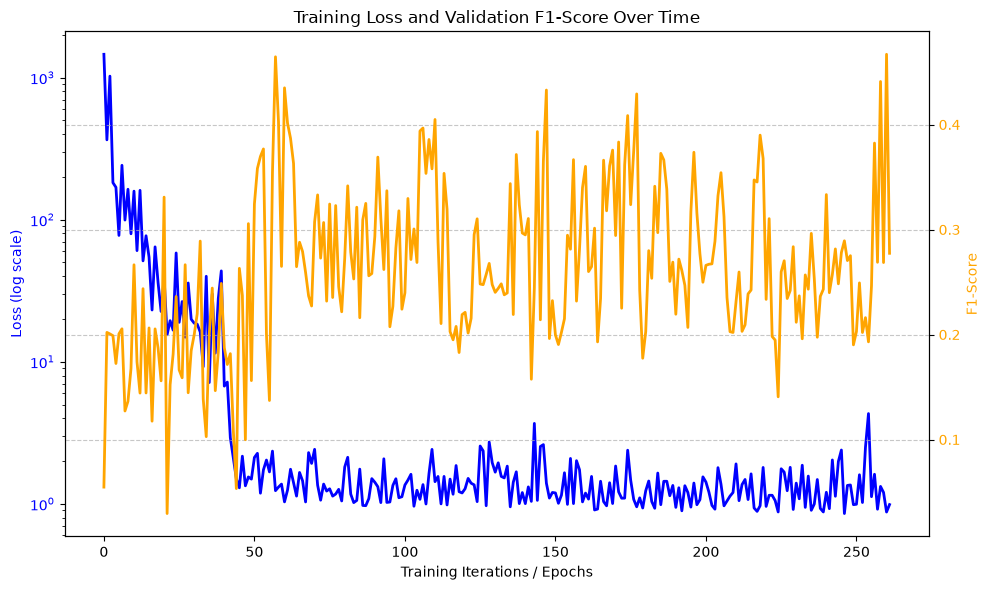

In [ ]:
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best hyperparameters for final training...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

print("\nStarting final training on Train dataset with validation...")

if minibatches:
    data = data.to(device)
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    final_train_loader = [d_dev]
    final_val_loader = [d_dev]

print(f"Batches per epoch (Final Train): {len(final_train_loader)}")

# Re-initialize the model with best parameters
final_model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_params['hidden_dim'],
    out_dim=best_params['out_dim'],
    heads=best_params['heads'],
    beta=best_params['beta'],
    mlp_hidden_dim=best_params['mlp_hidden_dim'],
    nn_t_hidden_dim=best_params['nn_t_hidden_dim'],
    minibatches=minibatches,
    gnn_type=gnn_type,
    num_layers=best_params['num_layers'],
    gin_mlp_hidden_dim=best_params['gin_mlp_hidden_dim']
).to(device)

final_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=best_params.get('laundry_weight', 2.0))
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
scaler = torch.amp.GradScaler('cuda')

os.makedirs(save_to_folder, exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches = 0
    
    for batch in final_train_loader:
        final_optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', dtype=torch.float16):
            p_node, p_trans, p_group, y_group = final_model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
            )
        
        if p_group.numel() > 0:
            loss, _, _, _ = final_criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=batch.node_mask,
                trans_mask=batch.edge_train_mask
            )
            scaler.scale(loss).backward()
            scaler.unscale_(final_optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params['max_norm'])
            scaler.step(final_optimizer)
            scaler.update()
            epoch_loss += loss.item()
            n_batches += 1
            
    train_loss = epoch_loss / max(n_batches, 1)
    final_model.training_losses.append(train_loss)
    
    # Validation step
    final_model.eval()
    all_preds = []
    all_labels = []
    evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    with torch.no_grad():
        for batch in final_val_loader:
            
            if hasattr(batch, 'e_id'):
                e_id = batch.e_id
                new_mask = ~evaluated_val[e_id]
                evaluated_val[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            val_mask = new_mask & batch.edge_val_mask
            if not val_mask.any():
                continue

            with torch.amp.autocast('cuda', dtype=torch.float16):
                p_node, p_trans, p_group, y_group = final_model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                )
            if p_group.numel() > 0:
                p_trans_val = p_trans[val_mask]
                y_trans_val = batch.y_trans[val_mask]
                probs = torch.sigmoid(p_trans_val)
                probs_flat = probs.view(-1)
                preds = (probs_flat >= 0.5).int()
                labels = y_trans_val.view(-1).long()
                all_preds.append(preds)
                all_labels.append(labels)
                
    if len(all_preds) > 0:
        all_preds = torch.cat(all_preds).cpu().numpy()
        all_labels = torch.cat(all_labels).cpu().numpy()
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)
    else:
        val_f1 = 0.0
        
    final_model.val_F1.append(val_f1)
    
    if (epoch + 1) % print_every == 0:
        print(f"Train Epoch {epoch+1:03d}/{epochs_train} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        
    window_size = min(len(final_model.val_F1), moving_average_epochs)
    ma_val_f1 = sum(final_model.val_F1[-window_size:]) / window_size

    if ma_val_f1 > best_final_val_f1:
        best_final_val_f1 = ma_val_f1
        epochs_no_improve = 0
        final_model.save(f"{save_to_folder}/model_trained_final.pt")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience_training:
        print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
        break
        
    # Save model every 10 epochs
    if (epoch + 1) % save_every == 0:
        final_model.save(f"{save_to_folder}/model_trained_{epoch+1}.pt")

print("\nPlotting training history of the final trained model...")
final_model.plot_training_history()



Loading best model for final evaluation on Test set...
    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.8424
  Precision : 0.6143
  Recall    : 0.4544
  F1-Score  : 0.5224
  ROC-AUC   : 0.8502
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.88      0.93      0.91      7679
  Laundering       0.61      0.45      0.52      1798

    accuracy                           0.84      9477
   macro avg       0.75      0.69      0.71      9477
weighted avg       0.83      0.84      0.83      9477



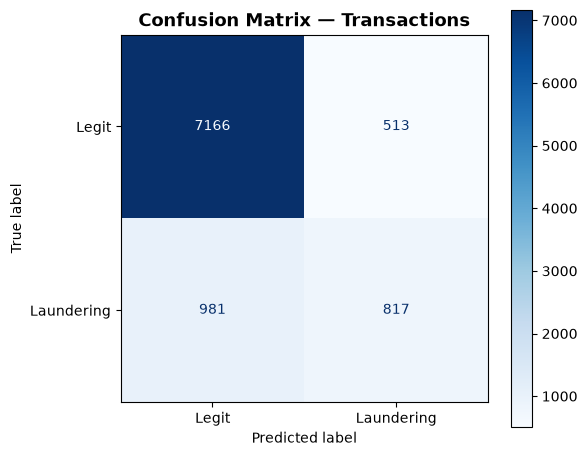

In [ ]:
from utils import Evaluator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best model for final evaluation on Test set...")
eval_model = GAGNN.load_saved(f"{save_to_folder}/model_trained_final.pt").to(device)

with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

eval_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'])

if minibatches:
    test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.evaluation_report(eval_model, test_loader, eval_criterion, device, edge_mask_name='edge_test_mask')
else:
    Evaluator.evaluation_report(eval_model, [d_dev], eval_criterion, device, edge_mask_name='edge_test_mask')


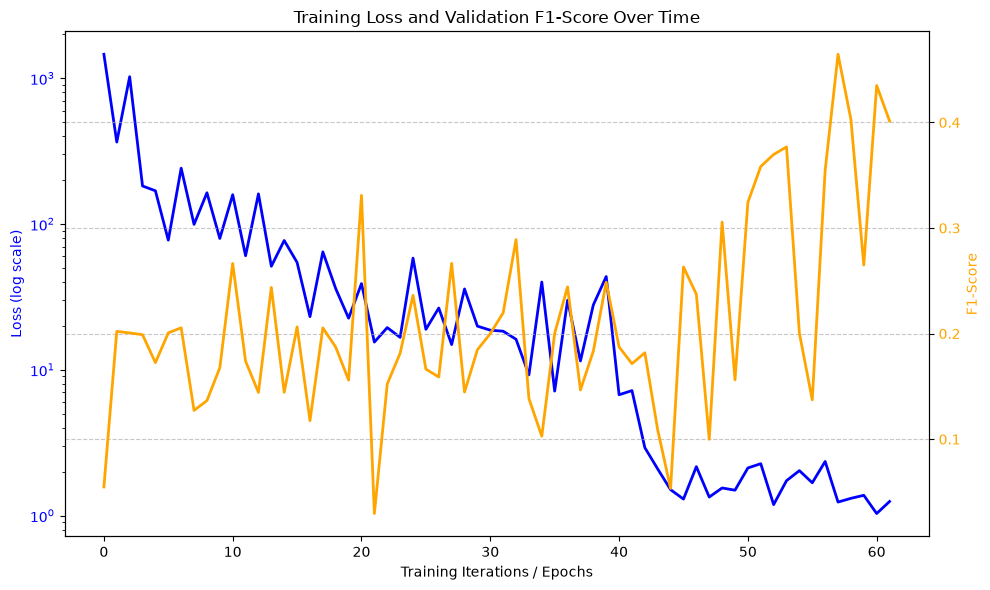

In [ ]:
eval_model.plot_training_history()

## Baseline: Standalone GIN (without GAGNN pipeline)

Ablation study: trains **only the GIN backbone** — no eMRF, no
GroupRepresentationLayer, no multi-task GAGNN loss — as a direct edge-level
Money Laundering classifier.

Edge features are used in the **EdgeMLP only** (this backbone has no native edge-feature support in message passing).

The same `data`, `train_node_mask`, `val_node_mask`, and `test_node_mask`
built earlier in this notebook are reused without modification.

In [ ]:
# =============================================================================
# Baseline GIN — Hyperparameter Grid
# =============================================================================
baseline_save_to_folder = 'saved_models_GIN/baseline'

baseline_hidden_dims = [64, 128]
baseline_out_dims = [64, 128, 256]
baseline_num_layers_list = [2, 3]
baseline_mlp_hidden_dims = [64, 128, 256]
baseline_learning_rates = [0.0005]
baseline_laundry_weights = [1.0, 2.0, 3.0]
baseline_max_norm_clipping = [5.0]

baseline_gin_mlp_hidden_dims = [64, 128]

baseline_epochs_model_selection = 3000
baseline_epochs_train = 6000

baseline_patience_selection = 100
baseline_moving_average_epochs = 5
moving_average_epochs = 5
baseline_patience_training  = 200


### Baseline — Model Selection

### Baseline — Training

In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
from model.standalone_gnn import StandaloneGNN, StandaloneGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best GAGNN hyperparameters to use for baseline...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_baseline_params = json.load(f)
print(best_baseline_params)

print("\nStarting baseline final training...")

if minibatches:
    data = data.to(device)
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    d_dev = data.to(device)
    final_train_loader = [d_dev]
    final_val_loader   = [d_dev]

final_model = StandaloneGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_baseline_params['hidden_dim'],
    out_dim=best_baseline_params['out_dim'],
    num_layers=best_baseline_params['num_layers'],
    gnn_type='gin',
    gin_mlp_hidden_dim=best_baseline_params['gin_mlp_hidden_dim'],
    mlp_hidden_dim=best_baseline_params['mlp_hidden_dim'],
    minibatches=minibatches,
).to(device)

final_criterion = StandaloneGNNLoss(
    laundry_weight=best_baseline_params['laundry_weight']
)
final_optimizer = torch.optim.Adam(
    final_model.parameters(), lr=best_baseline_params['lr']
)
scaler = torch.amp.GradScaler('cuda')

os.makedirs(baseline_save_to_folder, exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(baseline_epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for batch in final_train_loader:
        final_optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.float16):
                p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
                loss = final_criterion(p_trans, batch.y_trans, trans_mask=batch.edge_train_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(final_optimizer)
        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(), best_baseline_params['max_norm']
        )
        scaler.step(final_optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    final_model.training_losses.append(epoch_loss / max(n_batches, 1))

    # --- Validation ---
    final_model.eval()
    val_preds, val_labels = [], []
    evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    with torch.no_grad():
        for batch in final_val_loader:
            if hasattr(batch, 'e_id'):
                e_id     = batch.e_id
                new_mask = ~evaluated_val[e_id]
                evaluated_val[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            val_mask = new_mask & batch.edge_val_mask
            if not val_mask.any():
                continue
            with torch.amp.autocast('cuda', dtype=torch.float16):
                    p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
            probs   = torch.sigmoid(p_trans[val_mask].float()).view(-1)
            preds   = (probs >= 0.5).int()
            labels  = batch.y_trans[val_mask].view(-1).long()
            val_preds.append(preds)
            val_labels.append(labels)

    val_f1 = (
        f1_score(torch.cat(val_labels).cpu().numpy(), torch.cat(val_preds).cpu().numpy(), zero_division=0)
        if val_preds else 0.0
    )
    final_model.val_F1.append(val_f1)

    if epoch % print_every == 0:
        avg_loss = epoch_loss / max(n_batches, 1)
        print(f"Epoch {epoch + 1:4d} | Loss {avg_loss:.4f} | Val F1 {val_f1:.4f}")

    window_size = min(len(final_model.val_F1), moving_average_epochs)
    ma_val_f1 = sum(final_model.val_F1[-window_size:]) / window_size

    if ma_val_f1 > best_final_val_f1:
        best_final_val_f1 = ma_val_f1
        epochs_no_improve = 0
        final_model.save(f"{baseline_save_to_folder}/baseline_model_final.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= baseline_patience_training:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print(f"\nBest baseline val F1 (final training): {best_final_val_f1:.4f}")
print("Model saved to baseline_model_final.pt")



Loading best baseline hyperparameters...
{'max_norm': 5.0, 'hidden_dim': 64, 'out_dim': 64, 'num_layers': 2, 'mlp_hidden_dim': 256, 'lr': 0.0005, 'laundry_weight': 3.0, 'gin_mlp_hidden_dim': 64, 'nn_t_hidden_dim': 128}

Starting baseline final training...
Epoch    1 | Loss 26.2665 | Val F1 0.2645
Epoch   21 | Loss 2.5948 | Val F1 0.3613
Epoch   41 | Loss 1.7136 | Val F1 0.5255
Epoch   61 | Loss 1.2676 | Val F1 0.5403
Epoch   81 | Loss 1.6200 | Val F1 0.5606
Epoch  101 | Loss 0.4742 | Val F1 0.6120
Epoch  121 | Loss 1.1766 | Val F1 0.6589
Epoch  141 | Loss 0.8873 | Val F1 0.6516
Epoch  161 | Loss 3.8282 | Val F1 0.5840
Epoch  181 | Loss 1.1905 | Val F1 0.6790
Epoch  201 | Loss 0.4155 | Val F1 0.7119
Epoch  221 | Loss 3.8137 | Val F1 0.7010
Epoch  241 | Loss 0.6056 | Val F1 0.7002
Epoch  261 | Loss 0.3956 | Val F1 0.7241
Epoch  281 | Loss 0.7360 | Val F1 0.7228
Epoch  301 | Loss 1.4065 | Val F1 0.7110
Epoch  321 | Loss 1.5106 | Val F1 0.7073
Epoch  341 | Loss 0.6386 | Val F1 0.7081
Epoc

### Baseline — Evaluation on Test Set


Loading best baseline model for test evaluation...
  BASELINE EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.9254
  Precision : 0.7999
  Recall    : 0.8092
  F1-Score  : 0.8045
  ROC-AUC   : 0.9047
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.96      0.95      0.95      7679
  Laundering       0.80      0.81      0.80      1798

    accuracy                           0.93      9477
   macro avg       0.88      0.88      0.88      9477
weighted avg       0.93      0.93      0.93      9477



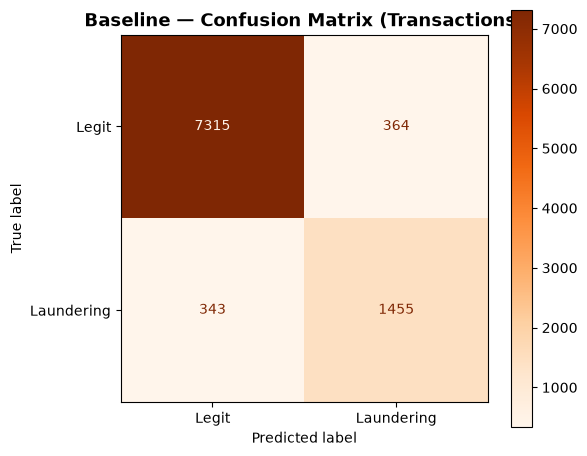

In [ ]:
from model.standalone_gnn import StandaloneGNN
from utils import Evaluator
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best baseline model for test evaluation...")
baseline_eval_model = StandaloneGNN.load_saved(
    f"{baseline_save_to_folder}/baseline_model_final.pt"
).to(device)

if minibatches:
    baseline_test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, baseline_test_loader, device,
        edge_mask_name='edge_test_mask'
    )
else:
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, [d_dev], device,
        edge_mask_name='edge_test_mask'
    )


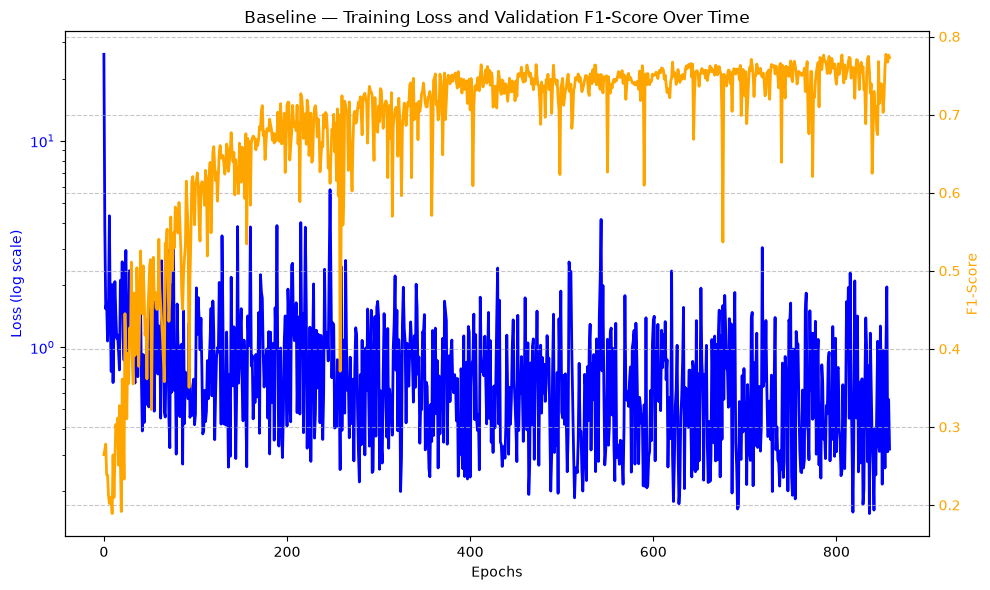

In [ ]:
baseline_eval_model.plot_training_history()